# LoRa 915 MHz Band Plan (AU915)

This notebook visualizes the complete **AU915 LoRaWAN band plan**, including:
- **Upstream 125 kHz** – 64 channels (0–63), DR0–DR5, 915.2–927.8 MHz
- **Upstream 500 kHz** – 8 channels (64–71), DR6, 915.9–927.1 MHz
- **LR-FHSS 1.523 MHz** – 8 channels (64–71), DR7, same center frequencies
- **Downstream 500 kHz** – 8 channels (0–7), DR8–DR13, 923.3–927.5 MHz
- **Wake on Radio (WOR)** – 2 channels + ACK at BW500, SF10

## 1. Import Required Libraries

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import numpy as np

## 2. Define Upstream 125 kHz Channels (0–63)

64 channels starting at **915.2 MHz**, incrementing by **200 kHz** to **927.8 MHz**.  
Modulation: LoRa 125 kHz BW | Data Rates: DR0–DR5 (optionally DR9–DR10) | Coding Rate: 4/5

In [16]:
# Upstream 125 kHz channels: 64 channels, 0–63
N_US125 = 64
us125_start = 915.2   # MHz
us125_step  = 0.200   # MHz
bw_125      = 0.125   # MHz  (125 kHz)

us125_freqs = [us125_start + i * us125_step for i in range(N_US125)]
us125_channels = []
for i, fc in enumerate(us125_freqs):
    us125_channels.append({
        "ch":   i,
        "fc":   fc,
        "bw":   bw_125,
        "dr":   "DR0–DR5 (+DR9,DR10)",
        "cr":   "4/5",
        "dir":  "upstream",
    })

print(f"US 125 kHz: {N_US125} channels")
print(f"  First: Ch 0  @ {us125_channels[0]['fc']:.1f} MHz")
print(f"  Last:  Ch 63 @ {us125_channels[-1]['fc']:.1f} MHz")

US 125 kHz: 64 channels
  First: Ch 0  @ 915.2 MHz
  Last:  Ch 63 @ 927.8 MHz


## 3. Define Upstream 500 kHz / LR-FHSS Channels (64–71)

8 channels starting at **915.9 MHz**, incrementing by **1.6 MHz** to **927.1 MHz**.  
- **DR6**: LoRa 500 kHz BW  
- **DR7**: LR-FHSS 1.523 MHz BW (same center frequencies)

In [17]:
# Upstream 500 kHz channels (DR6): 8 channels, 64–71
N_US500    = 8
us500_start = 915.9   # MHz
us500_step  = 1.6     # MHz
bw_500      = 0.500   # MHz  (500 kHz)
bw_lrfhss   = 1.523   # MHz  (LR-FHSS OCW)

us500_freqs = [us500_start + i * us500_step for i in range(N_US500)]
us500_channels = []   # DR6 – LoRa 500 kHz
lrfhss_channels = []  # DR7 – LR-FHSS 1.523 MHz

for i, fc in enumerate(us500_freqs):
    us500_channels.append({"ch": 64 + i, "fc": fc, "bw": bw_500,    "dr": "DR6", "dir": "upstream"})
    lrfhss_channels.append({"ch": 64 + i, "fc": fc, "bw": bw_lrfhss, "dr": "DR7", "dir": "upstream"})

print(f"US 500 kHz (DR6): {N_US500} channels")
for ch in us500_channels:
    print(f"  Ch {ch['ch']:2d}  @ {ch['fc']:.1f} MHz")

print(f"\nLR-FHSS 1.523 MHz (DR7): {N_US500} channels  (same center freqs, wider OBW)")

US 500 kHz (DR6): 8 channels
  Ch 64  @ 915.9 MHz
  Ch 65  @ 917.5 MHz
  Ch 66  @ 919.1 MHz
  Ch 67  @ 920.7 MHz
  Ch 68  @ 922.3 MHz
  Ch 69  @ 923.9 MHz
  Ch 70  @ 925.5 MHz
  Ch 71  @ 927.1 MHz

LR-FHSS 1.523 MHz (DR7): 8 channels  (same center freqs, wider OBW)


## 4. Define Downstream 500 kHz Channels (0–7)

8 channels starting at **923.3 MHz**, incrementing by **600 kHz** to **927.5 MHz**.  
Modulation: LoRa 500 kHz BW | Data Rates: DR8–DR13 (optionally DR14 and DR0)

In [18]:
# Downstream 500 kHz channels: 8 channels, 0–7
N_DS       = 8
ds_start   = 923.3   # MHz
ds_step    = 0.600   # MHz

ds_freqs   = [ds_start + i * ds_step for i in range(N_DS)]
ds_channels = []

for i, fc in enumerate(ds_freqs):
    ds_channels.append({
        "ch":  i,
        "fc":  fc,
        "bw":  bw_500,
        "dr":  "DR8–DR13 (+DR14,DR0)",
        "dir": "downstream",
    })

print(f"Downstream 500 kHz: {N_DS} channels")
for ch in ds_channels:
    print(f"  Ch {ch['ch']}  @ {ch['fc']:.1f} MHz")

Downstream 500 kHz: 8 channels
  Ch 0  @ 923.3 MHz
  Ch 1  @ 923.9 MHz
  Ch 2  @ 924.5 MHz
  Ch 3  @ 925.1 MHz
  Ch 4  @ 925.7 MHz
  Ch 5  @ 926.3 MHz
  Ch 6  @ 926.9 MHz
  Ch 7  @ 927.5 MHz


## 5. Define Wake on Radio (WOR) Channels

| WOR Channel | Beacon Freq | ACK Freq | SF | BW |
|:-----------:|:-----------:|:--------:|:--:|:--:|
| 0 | 916.7 MHz | 918.3 MHz | SF10 | 500 kHz |
| 1 | 919.9 MHz | 921.5 MHz | SF10 | 500 kHz |

In [19]:
# Wake on Radio channels
wor_channels = [
    {"ch": 0, "fc_beacon": 916.7, "fc_ack": 918.3, "sf": 10, "bw": bw_500},
    {"ch": 1, "fc_beacon": 919.9, "fc_ack": 921.5, "sf": 10, "bw": bw_500},
]

for w in wor_channels:
    print(f"WOR Ch {w['ch']}: Beacon @ {w['fc_beacon']} MHz  |  ACK @ {w['fc_ack']} MHz  |  SF{w['sf']} BW{int(w['bw']*1000)} kHz")

WOR Ch 0: Beacon @ 916.7 MHz  |  ACK @ 918.3 MHz  |  SF10 BW500 kHz
WOR Ch 1: Beacon @ 919.9 MHz  |  ACK @ 921.5 MHz  |  SF10 BW500 kHz


## 6. Plot Full Band Plan Visualization

Each horizontal band represents one channel type. Bar width = occupied bandwidth. Bars are centered on the channel's center frequency.

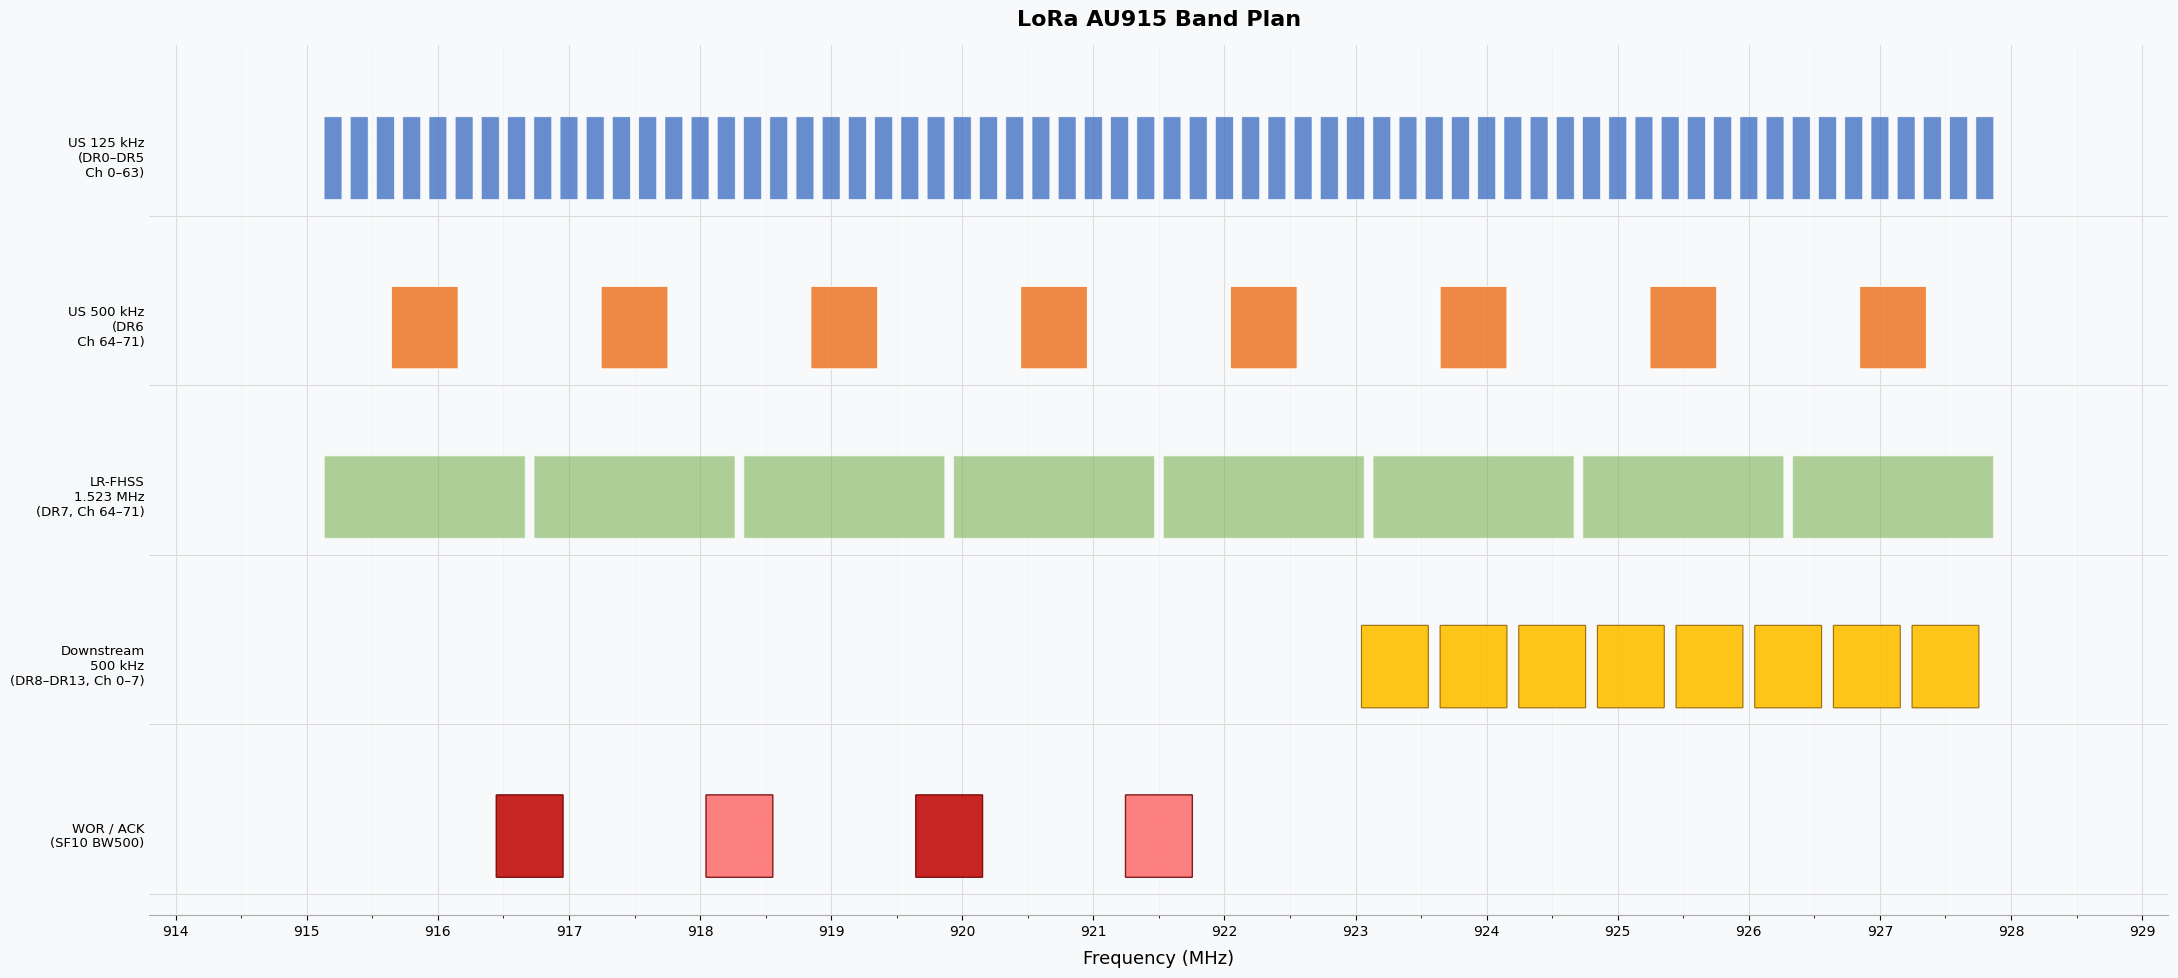

In [20]:
%matplotlib inline

# ── Color palette ──────────────────────────────────────────────────────────────
C_US125     = "#4472C4"   # blue         – upstream 125 kHz
C_US500     = "#ED7D31"   # orange       – upstream 500 kHz DR6
C_LRFHSS    = "#70AD47"   # green        – LR-FHSS DR7
C_DS        = "#FFC000"   # amber        – downstream 500 kHz
C_WOR       = "#C00000"   # dark red     – WOR beacon
C_WOR_ACK   = "#FF6B6B"   # light red    – WOR ACK
C_GRID      = "#DDDDDD"

# ── Row layout (y-center per layer) ───────────────────────────────────────────
ROW_H = 0.72   # bar height
rows = {
    "US 125 kHz\n(DR0–DR5\n Ch 0–63)":       5.5,
    "US 500 kHz\n(DR6\n Ch 64–71)":           4.0,
    "LR-FHSS\n1.523 MHz\n(DR7, Ch 64–71)":   2.5,
    "Downstream\n500 kHz\n(DR8–DR13, Ch 0–7)":1.0,
    "WOR / ACK\n(SF10 BW500)":               -0.5,
}

# ── Layout ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(22, 10))
fig.patch.set_facecolor("#F8F9FA")
ax.set_facecolor("#F8F9FA")


def draw_bar(ax, fc, bw, y, color, alpha=0.85, edgecolor="white", lw=0.4, zorder=2):
    """Draw a single channel bar centered at fc with given bw."""
    x0 = fc - bw / 2
    rect = mpatches.FancyBboxPatch(
        (x0, y - ROW_H / 2), bw, ROW_H,
        boxstyle="round,pad=0.005",
        linewidth=lw, edgecolor=edgecolor,
        facecolor=color, alpha=alpha, zorder=zorder,
    )
    ax.add_patch(rect)


# ── 1. Upstream 125 kHz (0–63) ────────────────────────────────────────────────
y_us125 = rows["US 125 kHz\n(DR0–DR5\n Ch 0–63)"]
for ch in us125_channels:
    draw_bar(ax, ch["fc"], ch["bw"], y_us125, C_US125, alpha=0.80)

# ── 2. Upstream 500 kHz DR6 (64–71) ──────────────────────────────────────────
y_us500 = rows["US 500 kHz\n(DR6\n Ch 64–71)"]
for ch in us500_channels:
    draw_bar(ax, ch["fc"], ch["bw"], y_us500, C_US500, alpha=0.90, lw=0.8)

# ── 3. LR-FHSS DR7 (64–71) ───────────────────────────────────────────────────
y_lrfhss = rows["LR-FHSS\n1.523 MHz\n(DR7, Ch 64–71)"]
for ch in lrfhss_channels:
    draw_bar(ax, ch["fc"], ch["bw"], y_lrfhss, C_LRFHSS, alpha=0.55, lw=0.8)

# ── 4. Downstream 500 kHz (0–7) ───────────────────────────────────────────────
y_ds = rows["Downstream\n500 kHz\n(DR8–DR13, Ch 0–7)"]
for ch in ds_channels:
    draw_bar(ax, ch["fc"], ch["bw"], y_ds, C_DS, alpha=0.90, edgecolor="#8B6000", lw=0.8)

# ── 5. WOR / ACK ─────────────────────────────────────────────────────────────
y_wor = rows["WOR / ACK\n(SF10 BW500)"]
for w in wor_channels:
    draw_bar(ax, w["fc_beacon"], w["bw"], y_wor, C_WOR,     alpha=0.85, edgecolor="#6B0000", lw=1.0, zorder=3)
    draw_bar(ax, w["fc_ack"],    w["bw"], y_wor, C_WOR_ACK, alpha=0.85, edgecolor="#6B0000", lw=1.0, zorder=3)


# ── Axes formatting ────────────────────────────────────────────────────────────
ax.set_xlim(913.8, 929.2)
ax.set_ylim(-1.2, 6.5)

ax.set_xlabel("Frequency (MHz)", fontsize=13, labelpad=8)
ax.set_title("LoRa AU915 Band Plan", fontsize=16, fontweight="bold", pad=14)

ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))
ax.tick_params(axis="x", labelsize=10)

ax.set_yticks(list(rows.values()))
ax.set_yticklabels(list(rows.keys()), fontsize=9.5, va="center")

ax.yaxis.set_tick_params(length=0)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#AAAAAA")

ax.xaxis.grid(True, which="major", color=C_GRID, linewidth=0.8, zorder=0)
ax.xaxis.grid(True, which="minor", color=C_GRID, linewidth=0.4, linestyle=":", zorder=0)
ax.set_axisbelow(True)

# Horizontal dividers between rows
for y in rows.values():
    ax.axhline(y - ROW_H / 2 - 0.15, color="#CCCCCC", linewidth=0.5, zorder=0)

plt.tight_layout(pad=1.5)
plt.show()

## 7. Add Channel Annotations and Legend

Full annotated plot with channel numbers, DR info, and WOR labels.

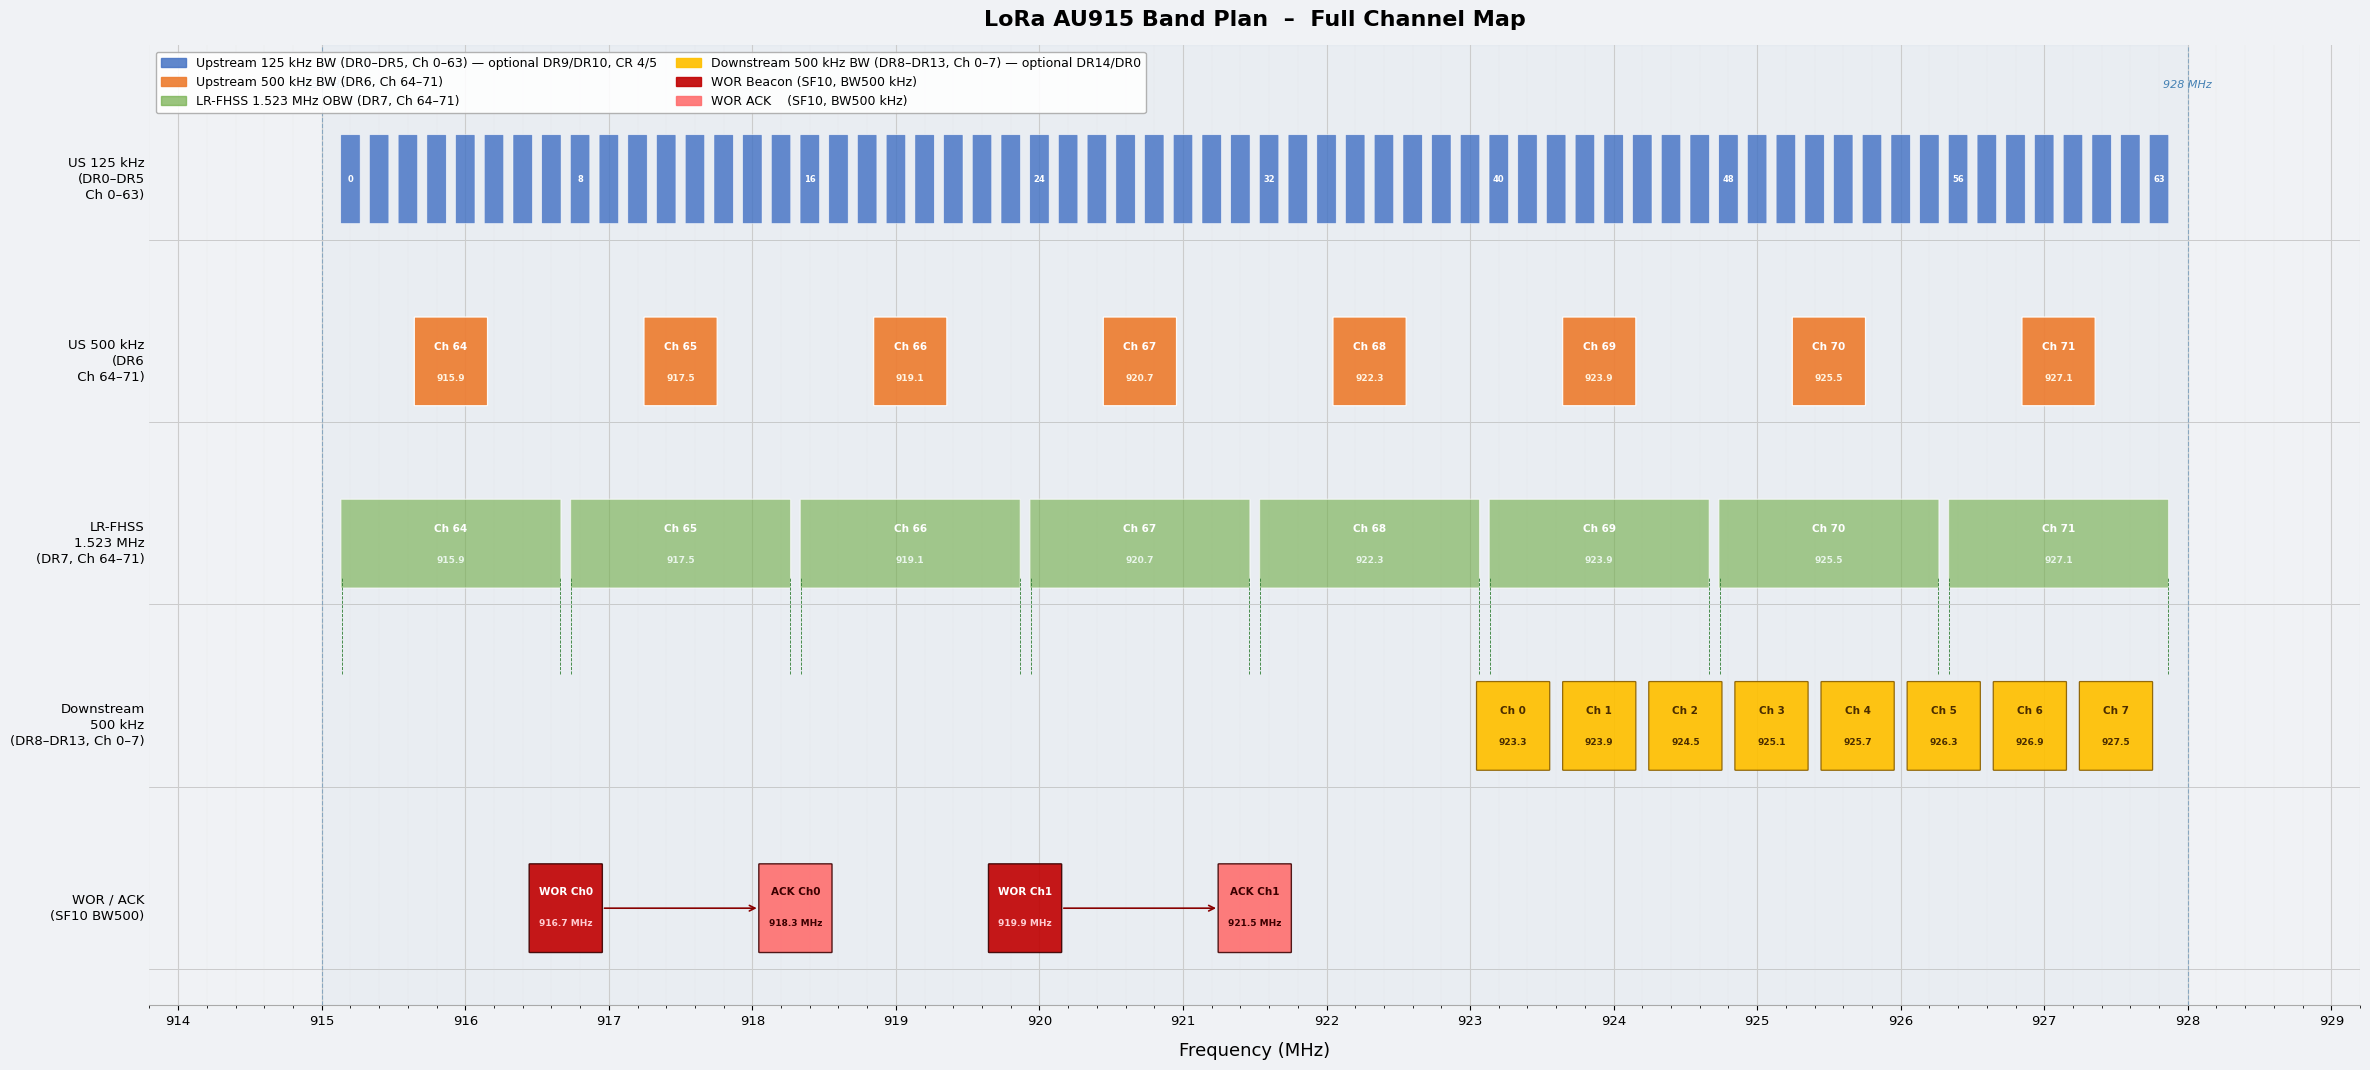

Saved → lora_915_band_plan.png


In [21]:
%matplotlib inline

# ── Full annotated band plan ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(24, 11))
fig.patch.set_facecolor("#F0F2F5")
ax.set_facecolor("#F0F2F5")


def draw_bar(ax, fc, bw, y, color, alpha=0.85, edgecolor="white", lw=0.4, zorder=2):
    x0 = fc - bw / 2
    rect = mpatches.FancyBboxPatch(
        (x0, y - ROW_H / 2), bw, ROW_H,
        boxstyle="round,pad=0.005",
        linewidth=lw, edgecolor=edgecolor,
        facecolor=color, alpha=alpha, zorder=zorder,
    )
    ax.add_patch(rect)


def label(ax, x, y, txt, fontsize=6.5, color="white", va="center", **kw):
    ax.text(x, y, txt, ha="center", va=va, fontsize=fontsize,
            color=color, fontweight="bold", clip_on=True, **kw)


# ── Draw US 125 kHz ───────────────────────────────────────────────────────────
y_us125 = rows["US 125 kHz\n(DR0–DR5\n Ch 0–63)"]
for ch in us125_channels:
    draw_bar(ax, ch["fc"], ch["bw"], y_us125, C_US125, alpha=0.82)
    if ch["ch"] % 8 == 0 or ch["ch"] == 63:   # label every 8th + last
        label(ax, ch["fc"], y_us125, str(ch["ch"]), fontsize=6.0)

# ── Draw US 500 kHz DR6 ───────────────────────────────────────────────────────
y_us500 = rows["US 500 kHz\n(DR6\n Ch 64–71)"]
for ch in us500_channels:
    draw_bar(ax, ch["fc"], ch["bw"], y_us500, C_US500, alpha=0.92, lw=0.9)
    label(ax, ch["fc"], y_us500 + 0.12, f"Ch {ch['ch']}", fontsize=7.5)
    label(ax, ch["fc"], y_us500 - 0.14, f"{ch['fc']:.1f}", fontsize=6.5, color="#FFF3E0")

# ── Draw LR-FHSS DR7 ──────────────────────────────────────────────────────────
y_lrfhss = rows["LR-FHSS\n1.523 MHz\n(DR7, Ch 64–71)"]
for ch in lrfhss_channels:
    draw_bar(ax, ch["fc"], ch["bw"], y_lrfhss, C_LRFHSS, alpha=0.60, lw=0.9)
    label(ax, ch["fc"], y_lrfhss + 0.12, f"Ch {ch['ch']}", fontsize=7.5)
    label(ax, ch["fc"], y_lrfhss - 0.14, f"{ch['fc']:.1f}", fontsize=6.5, color="#E8F5E9")

# Show OBW boundary dashes for LR-FHSS
for ch in lrfhss_channels:
    for side in [-1, 1]:
        ax.axvline(ch["fc"] + side * ch["bw"] / 2,
                   ymin=0.345, ymax=0.445,
                   color="#2E7D32", linewidth=0.6, linestyle="--", zorder=4)

# ── Draw Downstream 500 kHz ───────────────────────────────────────────────────
y_ds = rows["Downstream\n500 kHz\n(DR8–DR13, Ch 0–7)"]
for ch in ds_channels:
    draw_bar(ax, ch["fc"], ch["bw"], y_ds, C_DS, alpha=0.92, edgecolor="#8B6000", lw=0.9)
    label(ax, ch["fc"], y_ds + 0.12, f"Ch {ch['ch']}", fontsize=7.5, color="#4A2C00")
    label(ax, ch["fc"], y_ds - 0.14, f"{ch['fc']:.1f}", fontsize=6.5, color="#4A2C00")

# ── Draw WOR / ACK ────────────────────────────────────────────────────────────
y_wor = rows["WOR / ACK\n(SF10 BW500)"]
for w in wor_channels:
    # Beacon
    draw_bar(ax, w["fc_beacon"], w["bw"], y_wor, C_WOR, alpha=0.90, edgecolor="#3B0000", lw=1.0, zorder=3)
    label(ax, w["fc_beacon"], y_wor + 0.13, f"WOR Ch{w['ch']}", fontsize=7.5)
    label(ax, w["fc_beacon"], y_wor - 0.13, f"{w['fc_beacon']} MHz", fontsize=6.5, color="#FFCDD2")

    # ACK
    draw_bar(ax, w["fc_ack"], w["bw"], y_wor, C_WOR_ACK, alpha=0.88, edgecolor="#3B0000", lw=1.0, zorder=3)
    label(ax, w["fc_ack"], y_wor + 0.13, f"ACK Ch{w['ch']}", fontsize=7.5, color="#3B0000")
    label(ax, w["fc_ack"], y_wor - 0.13, f"{w['fc_ack']} MHz", fontsize=6.5, color="#3B0000")

    # Arrow beacon → ack
    ax.annotate(
        "", xy=(w["fc_ack"] - w["bw"] / 2, y_wor),
        xytext=(w["fc_beacon"] + w["bw"] / 2, y_wor),
        arrowprops=dict(arrowstyle="->", color="#880000", lw=1.2),
        zorder=5,
    )

# ── Frequency band shade: AU915 plan limits ───────────────────────────────────
ax.axvspan(915.0, 928.0, alpha=0.04, color="steelblue", zorder=0)
ax.axvline(915.0, color="steelblue", lw=0.8, linestyle="--", alpha=0.5, zorder=1)
ax.axvline(928.0, color="steelblue", lw=0.8, linestyle="--", alpha=0.5, zorder=1)
ax.text(915.0, 6.25, "915 MHz", ha="center", fontsize=8, color="steelblue", fontstyle="italic")
ax.text(928.0, 6.25, "928 MHz", ha="center", fontsize=8, color="steelblue", fontstyle="italic")

# ── Axes ──────────────────────────────────────────────────────────────────────
ax.set_xlim(913.8, 929.2)
ax.set_ylim(-1.3, 6.6)
ax.set_xlabel("Frequency (MHz)", fontsize=13, labelpad=10)
ax.set_title("LoRa AU915 Band Plan  –  Full Channel Map", fontsize=16, fontweight="bold", pad=14)

ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.2))
ax.tick_params(axis="x", labelsize=9.5, which="major")

ax.set_yticks(list(rows.values()))
ax.set_yticklabels(list(rows.keys()), fontsize=9.5, va="center", linespacing=1.3)
ax.yaxis.set_tick_params(length=0)

ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#AAAAAA")
ax.xaxis.grid(True, which="major", color="#CCCCCC", linewidth=0.8, zorder=0)
ax.xaxis.grid(True, which="minor", color="#DDDDDD", linewidth=0.3, linestyle=":", zorder=0)
ax.set_axisbelow(True)

for y in rows.values():
    ax.axhline(y - ROW_H / 2 - 0.14, color="#BBBBBB", linewidth=0.5, zorder=0)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_entries = [
    mpatches.Patch(color=C_US125,   alpha=0.85, label="Upstream 125 kHz BW (DR0–DR5, Ch 0–63) — optional DR9/DR10, CR 4/5"),
    mpatches.Patch(color=C_US500,   alpha=0.92, label="Upstream 500 kHz BW (DR6, Ch 64–71)"),
    mpatches.Patch(color=C_LRFHSS,  alpha=0.70, label="LR-FHSS 1.523 MHz OBW (DR7, Ch 64–71)"),
    mpatches.Patch(color=C_DS,      alpha=0.92, label="Downstream 500 kHz BW (DR8–DR13, Ch 0–7) — optional DR14/DR0"),
    mpatches.Patch(color=C_WOR,     alpha=0.90, label="WOR Beacon (SF10, BW500 kHz)"),
    mpatches.Patch(color=C_WOR_ACK, alpha=0.88, label="WOR ACK    (SF10, BW500 kHz)"),
]
ax.legend(handles=legend_entries, loc="upper left",
          fontsize=9, framealpha=0.9, edgecolor="#AAAAAA",
          bbox_to_anchor=(0.0, 1.0), ncol=2, columnspacing=1.5)

plt.tight_layout(pad=1.8)
plt.savefig("lora_915_band_plan.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Saved → lora_915_band_plan.png")